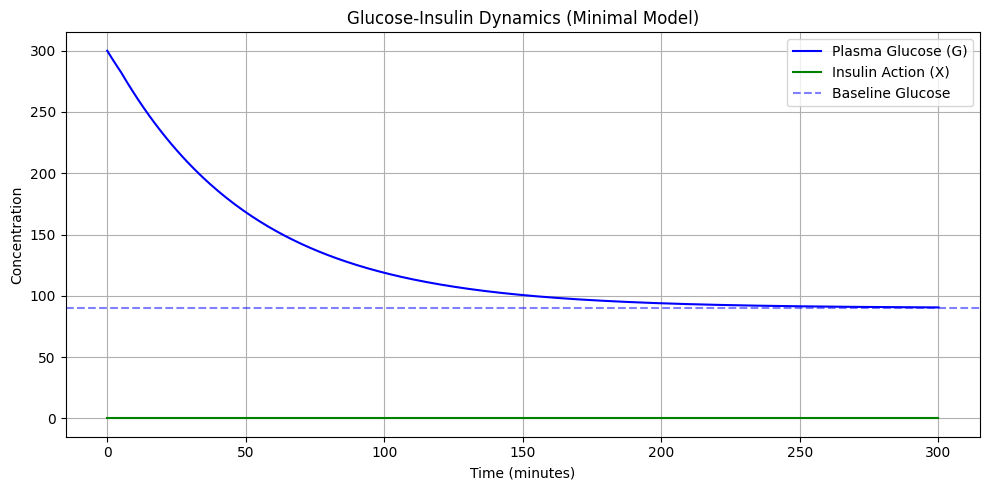

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the minimal model equations
def minimal_model(y, t, p1, p2, p3, Gb, Ib, D_func):
    G, X = y
    I = Ib  # assume insulin stays constant in this simple model
    D = D_func(t)  # external glucose input (e.g., meal or glucose injection)
    
    dGdt = -p1 * (G - Gb) - X * G + D
    dXdt = -p2 * X + p3 * (I - Ib)
    
    return [dGdt, dXdt]

# Time points
t = np.linspace(0, 300, 300)  # 0 to 300 minutes

# Parameters (example values for a healthy individual)
p1 = 0.02   # min^-1
p2 = 0.025  # min^-1
p3 = 0.00013  # (1/min^2)
Gb = 90     # mg/dL (baseline glucose)
Ib = 15     # µU/mL (baseline insulin)

# Initial conditions: [G(0), X(0)]
G0 = 300  # high glucose after a meal or glucose injection
X0 = 0    # no initial insulin action
y0 = [G0, X0]

# Define external glucose input D(t) as a short bolus at t=0
def D_func(t):
    if t < 5:  # simulate a bolus over first 5 minutes
        return 0.5  # mg/dL/min
    else:
        return 0

# Solve ODE
solution = odeint(minimal_model, y0, t, args=(p1, p2, p3, Gb, Ib, D_func))
G, X = solution.T

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t, G, label='Plasma Glucose (G)', color='blue')
plt.plot(t, X, label='Insulin Action (X)', color='green')
plt.axhline(Gb, color='blue', linestyle='--', alpha=0.5, label='Baseline Glucose')
plt.xlabel('Time (minutes)')
plt.ylabel('Concentration')
plt.title('Glucose-Insulin Dynamics (Minimal Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
